In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
#import numpy as np


In [3]:
# Categorical features
CAT_FEATURES = [
    "education_level",
    "moderate_every_X_days",
    "vigorous_every_X_days",
    "has_partner",
    "had_partner",
    "is_female",
    "ever_smoker",
    "is_current_smoker",
    "drinking_frequency",
]

EXCLUDED_FEATURES = ["WTMEC2YR"]

TARGET = "has_diabetes_or_prediabetes"

In [4]:
df = pd.read_csv("../dataset/processed_data.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6336 entries, 0 to 6335
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RIDAGEYR                     6336 non-null   int64  
 1   DMDHHSIZ                     6336 non-null   int64  
 2   BMXBMI                       6234 non-null   float64
 3   BMXWAIST                     6018 non-null   float64
 4   BMXWT                        6247 non-null   float64
 5   BMXHT                        6261 non-null   float64
 6   PAD790Q                      6298 non-null   float64
 7   moderate_every_X_days        5031 non-null   float64
 8   PAD800                       5018 non-null   float64
 9   PAD810Q                      6303 non-null   float64
 10  vigorous_every_X_days        2876 non-null   float64
 11  PAD820                       2867 non-null   float64
 12  PAD680                       6289 non-null   float64
 13  WTMEC2YR          

In [6]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [7]:
# Get numerical columns (excluding categorical, target, and excluded features)
all_excluded = CAT_FEATURES + EXCLUDED_FEATURES + [TARGET]
numerical_cols = [col for col in df.columns if col not in all_excluded]
print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {CAT_FEATURES}")
print(f"Target: {TARGET}")

Numerical columns: ['RIDAGEYR', 'DMDHHSIZ', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT', 'PAD790Q', 'PAD800', 'PAD810Q', 'PAD820', 'PAD680', 'systolic_bp', 'diastolic_bp', 'drinks_per_day', 'binge_episodes_month']
Categorical columns: ['education_level', 'moderate_every_X_days', 'vigorous_every_X_days', 'has_partner', 'had_partner', 'is_female', 'ever_smoker', 'is_current_smoker', 'drinking_frequency']
Target: has_diabetes_or_prediabetes


<Axes: >

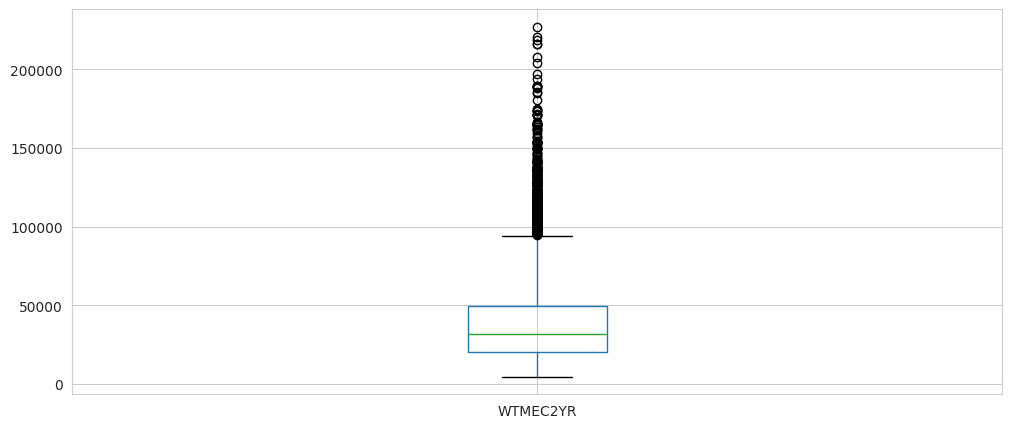

In [8]:
df[EXCLUDED_FEATURES].boxplot()

---

In [9]:
PA_FEATURES = ["PAD790Q",      # Moderate activity frequency
    "moderate_every_X_days",      # how many days in between
    "PAD800",       # Moderate activity minutes per session
    "PAD810Q",      # Vigorous activity frequency
    "vigorous_every_X_days",      # how many days in between
    "PAD820",       # Vigorous activity minutes per session
    "PAD680",       # Sedentary minutes per day
]

In [10]:
df[PA_FEATURES].describe()

,PAD790Q,moderate_every_X_days,PAD800,PAD810Q,vigorous_every_X_days,PAD820,PAD680
count,6298.000000,5031.000000,5018.000000,6303.000000,2876.000000,2867.000000,6289.000000
mean,2.658781,12.521765,63.189318,1.161828,26.429416,60.274852,365.092384
std,2.820210,40.884037,59.373539,2.378329,71.888684,60.592577,208.965021
min,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1.000000,7.000000,30.000000,0.000000,7.000000,30.000000,180.000000
50%,2.000000,7.000000,55.000000,0.000000,7.000000,45.000000,300.000000
75%,4.000000,7.000000,60.000000,2.000000,7.000000,60.000000,480.000000
max,104.000000,365.000000,720.000000,90.000000,365.000000,900.000000,1380.000000


---

## Distribution Comparison for Numerical Features

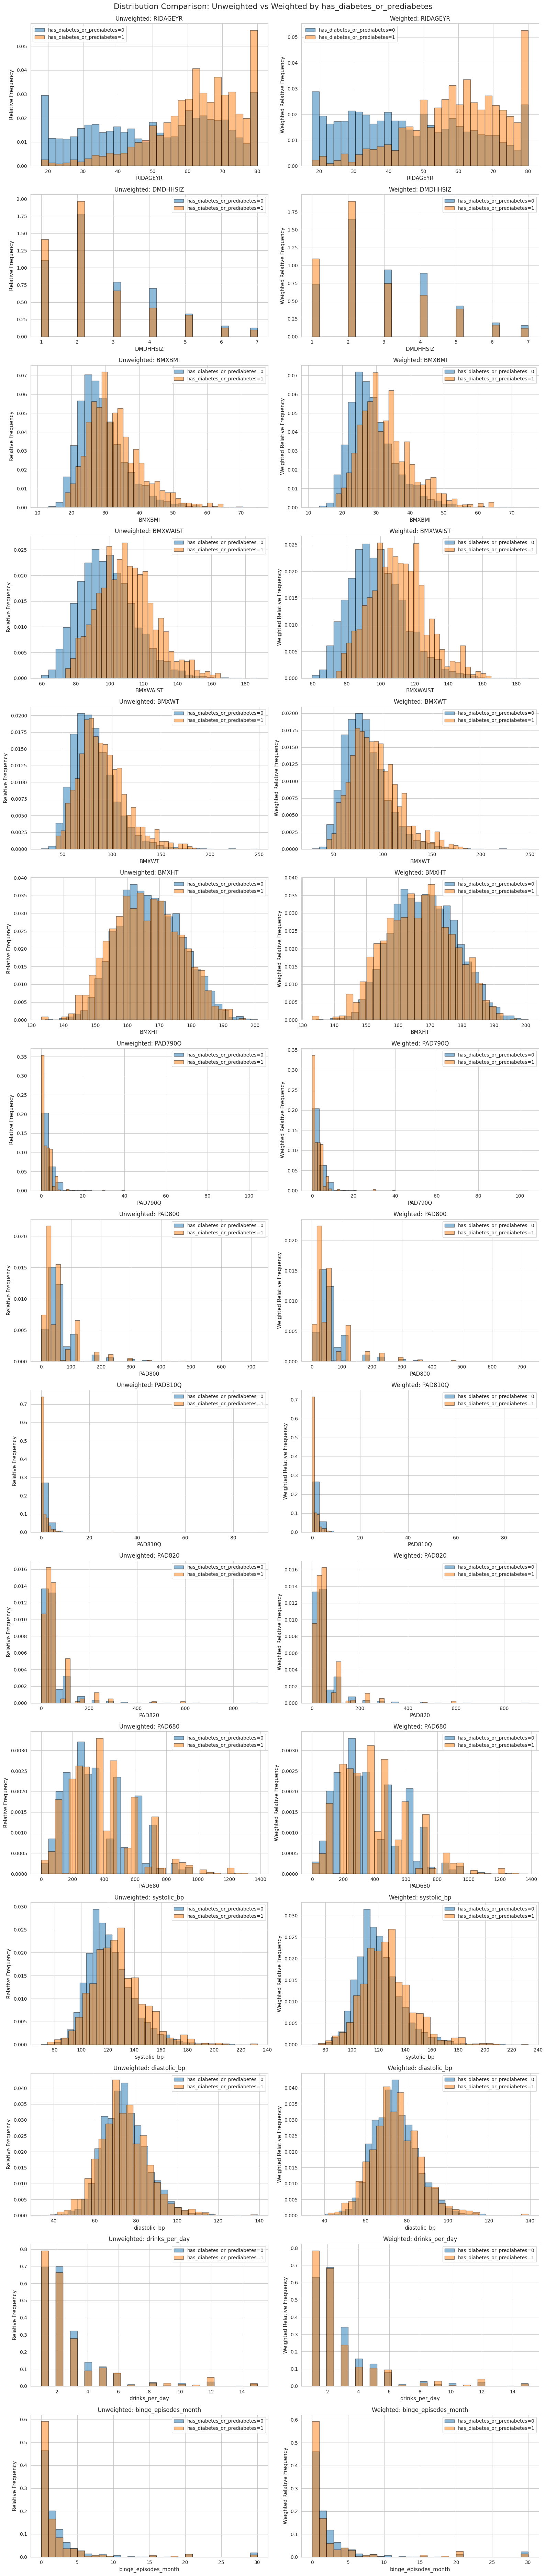

In [11]:
# Define the sample weight column
SAMPLE_WEIGHT = "WTMEC2YR"

# Get data for each target level
target_levels = df[TARGET].unique()

# Calculate number of rows needed (1 feature per row, 2 plots per feature)
n_features = len(numerical_cols)

# Create a single large figure with all numerical features
fig, axes = plt.subplots(n_features, 2, figsize=(16, 5 * n_features))

# Handle case where there's only one feature (axes won't be 2D)
if n_features == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numerical_cols):
    # Left plot: Unweighted
    ax_unweighted = axes[idx, 0]
    for level in target_levels:
        data = df[df[TARGET] == level][col].dropna()
        ax_unweighted.hist(data, bins=30, alpha=0.5, label=f'{TARGET}={level}', 
                          edgecolor='black', density=True)
    
    ax_unweighted.set_xlabel(col, fontsize=11)
    ax_unweighted.set_ylabel('Relative Frequency', fontsize=11)
    ax_unweighted.set_title(f'Unweighted: {col}', fontsize=12)
    ax_unweighted.legend(fontsize=10)
    
    # Right plot: Weighted
    ax_weighted = axes[idx, 1]
    for level in target_levels:
        mask = df[TARGET] == level
        data = df[mask][col].dropna()
        weights = df[mask].loc[data.index, SAMPLE_WEIGHT]
        
        ax_weighted.hist(data, bins=30, alpha=0.5, label=f'{TARGET}={level}', 
                        edgecolor='black', density=True, weights=weights)
    
    ax_weighted.set_xlabel(col, fontsize=11)
    ax_weighted.set_ylabel('Weighted Relative Frequency', fontsize=11)
    ax_weighted.set_title(f'Weighted: {col}', fontsize=12)
    ax_weighted.legend(fontsize=10)

fig.suptitle(f'Distribution Comparison: Unweighted vs Weighted by {TARGET}', 
             fontsize=16, y=0.998)
plt.tight_layout()
plt.show()

## Cross Tables for Categorical Features

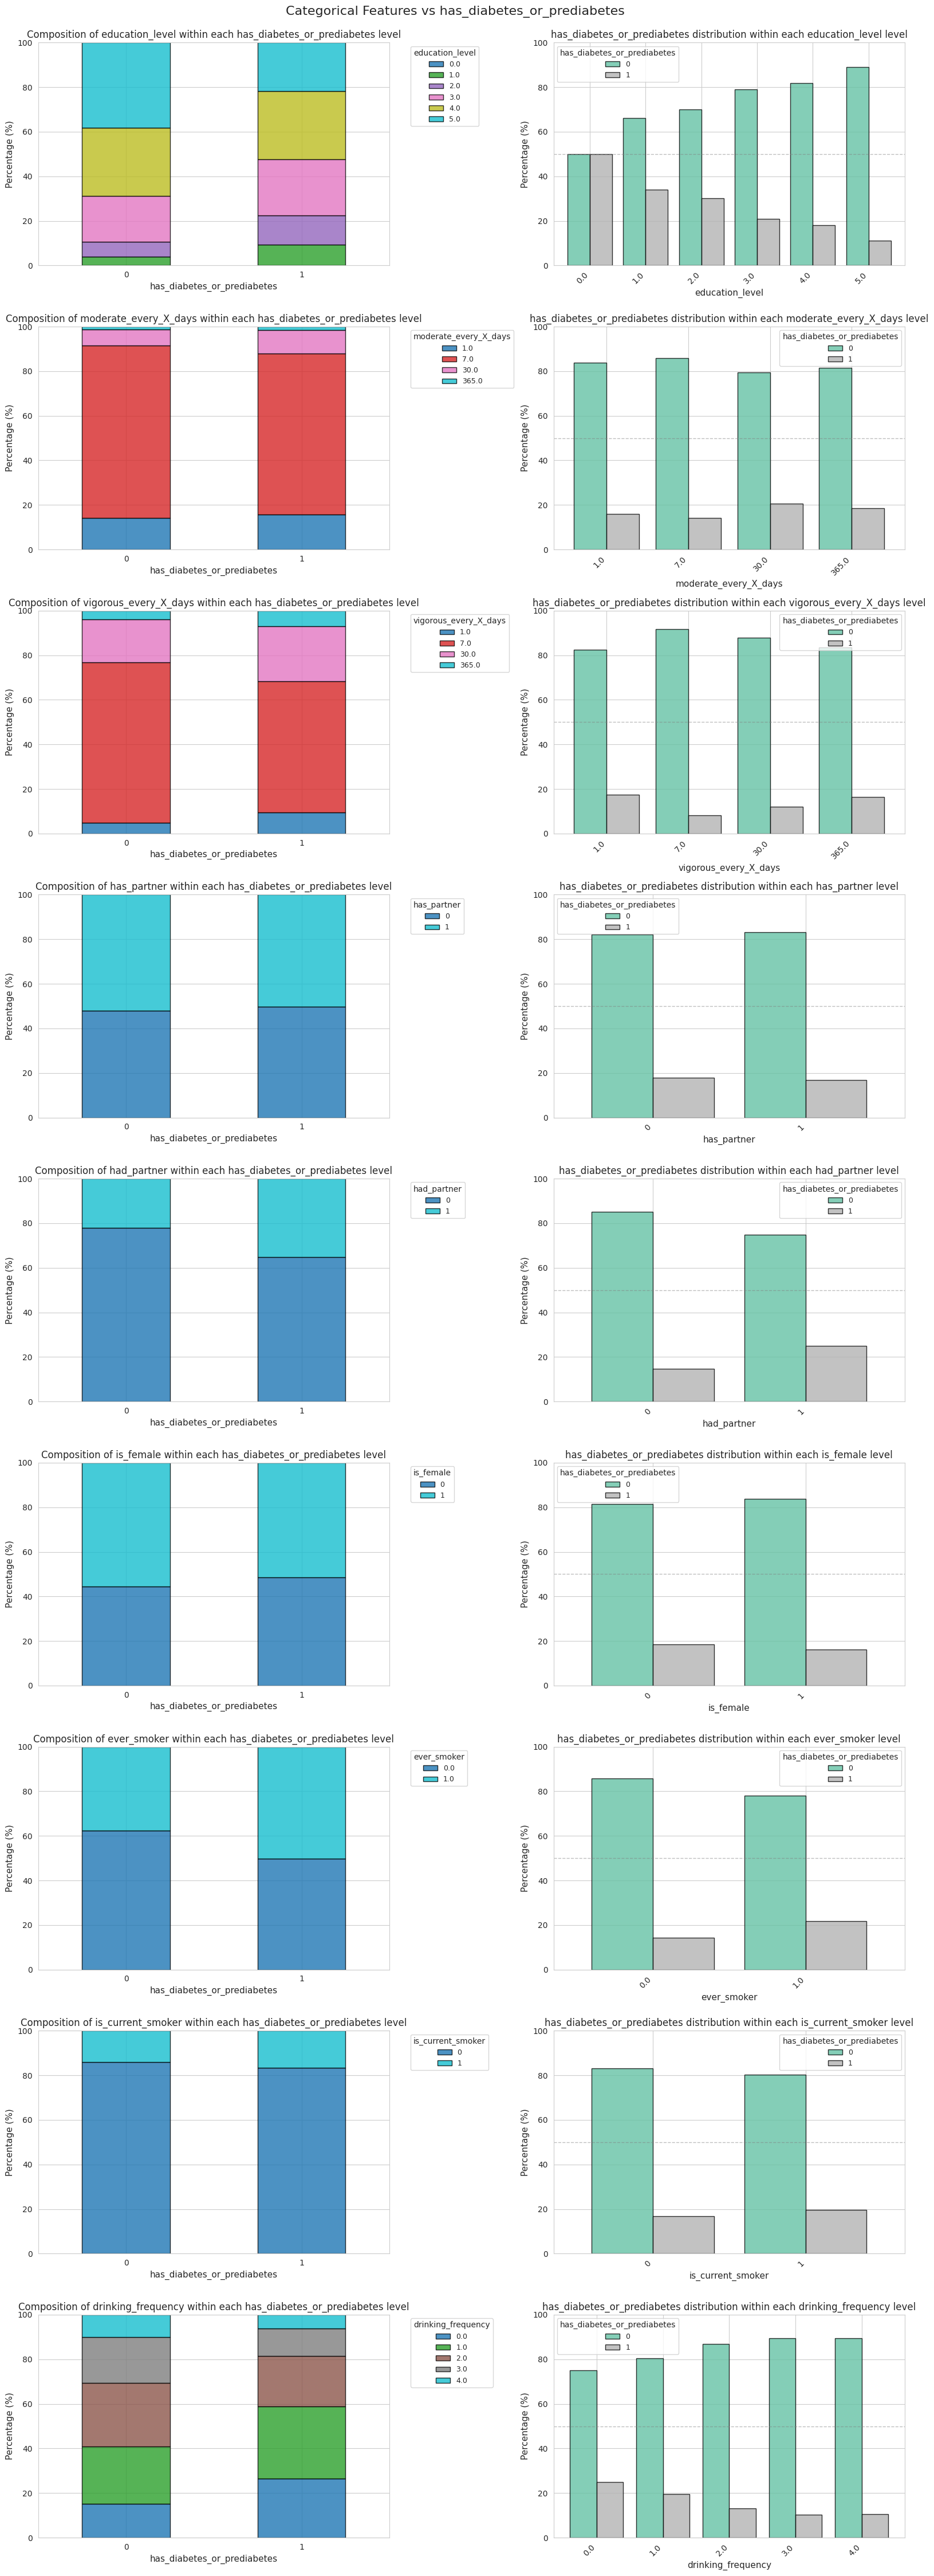

In [12]:
# Create visualizations for categorical features
n_cat_features = len(CAT_FEATURES)

# Create a single large figure with all categorical features
fig, axes = plt.subplots(n_cat_features, 2, figsize=(16, 5 * n_cat_features))

# Handle case where there's only one feature (axes won't be 2D)
if n_cat_features == 1:
    axes = axes.reshape(1, -1)

for idx, cat_col in enumerate(CAT_FEATURES):
    # Left plot: Stacked bar chart showing composition within each target level
    cross_tab = pd.crosstab(df[cat_col], df[TARGET])
    cross_tab_pct = cross_tab.div(cross_tab.sum(axis=0), axis=1) * 100
    
    cross_tab_pct.T.plot(kind='bar', stacked=True, ax=axes[idx, 0], 
                         colormap='tab10', alpha=0.8, edgecolor='black')
    axes[idx, 0].set_xlabel(TARGET, fontsize=11)
    axes[idx, 0].set_ylabel('Percentage (%)', fontsize=11)
    axes[idx, 0].set_title(f'Composition of {cat_col} within each {TARGET} level', fontsize=12)
    axes[idx, 0].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[idx, 0].set_xticklabels(axes[idx, 0].get_xticklabels(), rotation=0)
    axes[idx, 0].set_ylim(0, 100)
    
    # Right plot: Grouped bar chart showing target distribution within each feature level
    cross_tab_row_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
    
    cross_tab_row_pct.plot(kind='bar', ax=axes[idx, 1], 
                           colormap='Set2', alpha=0.8, edgecolor='black', width=0.8)
    axes[idx, 1].set_xlabel(cat_col, fontsize=11)
    axes[idx, 1].set_ylabel('Percentage (%)', fontsize=11)
    axes[idx, 1].set_title(f'{TARGET} distribution within each {cat_col} level', fontsize=12)
    axes[idx, 1].legend(title=TARGET, fontsize=9)
    axes[idx, 1].set_xticklabels(axes[idx, 1].get_xticklabels(), rotation=45, ha='right')
    axes[idx, 1].set_ylim(0, 100)
    axes[idx, 1].axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)

fig.suptitle(f'Categorical Features vs {TARGET}', fontsize=16, y=0.998)
plt.tight_layout()
plt.show()

In [13]:
df.loc[df['has_diabetes_or_prediabetes'] == 1]['vigorous_every_X_days'].value_counts()

vigorous_every_X_days
7.0      166
30.0      69
1.0       27
365.0     20
Name: count, dtype: int64

In [14]:
df.loc[df['has_diabetes_or_prediabetes'] == 0]['vigorous_every_X_days'].value_counts()

vigorous_every_X_days
7.0      1862
30.0      502
1.0       128
365.0     102
Name: count, dtype: int64

In [15]:
df['has_diabetes_or_prediabetes'].value_counts()

has_diabetes_or_prediabetes
0    5243
1    1093
Name: count, dtype: int64